## 1. Chargement et Exploration des Données

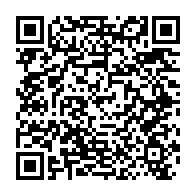

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np

# --- Chargement du dataset Contrôle Interne COSO/OECCA ---
df = pd.read_excel('base_controle_interne_COSO_OECCA.xlsx', sheet_name='Base_Entreprises')

# Colonnes numériques (5 composantes COSO + 3 COBIT + 2 indicateurs opérationnels)
num_cols = [
    'COSO_Env_Contrôle', 'COSO_Éval_Risques', 'COSO_Act_Contrôle',
    'COSO_Info_Communication', 'COSO_Supervision',
    'COBIT_Maturité_SI', 'COBIT_Alignement_Strat', 'COBIT_Conformité',
    'Ratio_Frais_Contrôle_CA', 'Taux_Anomalies_Détectées_%'
]

X     = df[num_cols].values          # (30, 10)
y     = df['Niveau_Maturité'].values # 1=Initial, 2=Répétable, 3=Défini, 4=Optimisé
y_cat = df['Classe_Maturité'].values # Initial, Répétable, Défini, Optimisé

# --- Normalisation : StandardScaler met chaque feature à N(0,1) ---
scaler = StandardScaler()
X_s    = scaler.fit_transform(X)

# --- PCA 2D (données complètes — 30 entreprises) ---
np.random.seed(42)

pca_2d  = PCA(n_components=2)
X_2d    = pca_2d.fit_transform(X_s)  # (30, 2)

print(f'Données normalisées  : {X_s.shape}')
print(f'Nombre de features   : {len(num_cols)} (5 COSO + 3 COBIT + 2 indicateurs)')
print(f'Classes de maturité  : {np.unique(y_cat)}')
print(f'PCA 2D variance expl.: {pca_2d.explained_variance_ratio_.sum()*100:.1f}%')

Données normalisées  : (30, 10)
Nombre de features   : 10 (5 COSO + 3 COBIT + 2 indicateurs)
Classes de maturité  : ['Défini' 'Initial' 'Optimisé' 'Répétable']
PCA 2D variance expl.: 36.0%


### Visualisations Exploratoires

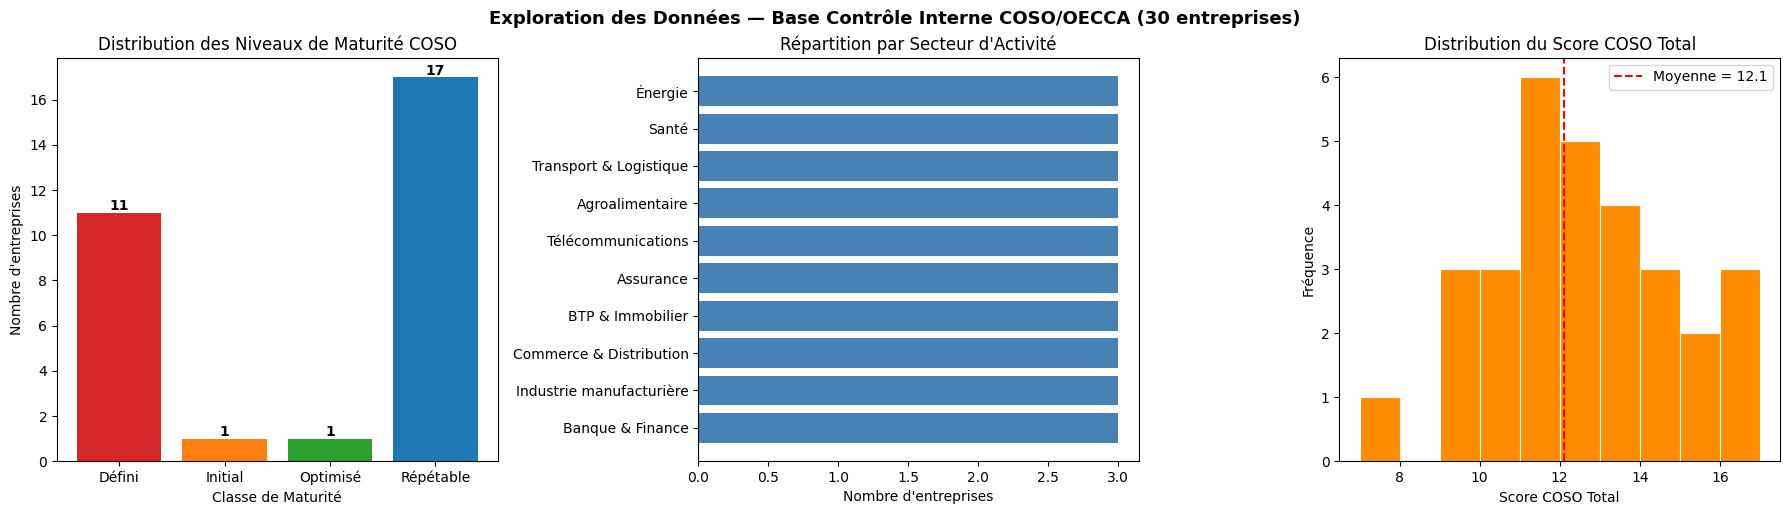

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribution des classes de maturité
classes, counts = np.unique(y_cat, return_counts=True)
colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']
axes[0].bar(classes, counts, color=colors[:len(classes)])
axes[0].set_title('Distribution des Niveaux de Maturité COSO')
axes[0].set_xlabel('Classe de Maturité')
axes[0].set_ylabel('Nombre d\'entreprises')
for i, (c, v) in enumerate(zip(classes, counts)):
    axes[0].text(i, v + 0.1, str(v), ha='center', fontweight='bold')

# Distribution des secteurs d'activité
secteurs = df['Secteur_Activité'].value_counts()
axes[1].barh(secteurs.index, secteurs.values, color='steelblue')
axes[1].set_title('Répartition par Secteur d\'Activité')
axes[1].set_xlabel('Nombre d\'entreprises')

# Distribution du Score COSO Total
axes[2].hist(df['Score_COSO_Total'], bins=10, color='darkorange', edgecolor='white', linewidth=0.8)
axes[2].set_title('Distribution du Score COSO Total')
axes[2].set_xlabel('Score COSO Total')
axes[2].set_ylabel('Fréquence')
axes[2].axvline(df['Score_COSO_Total'].mean(), color='red', linestyle='--', label=f'Moyenne = {df["Score_COSO_Total"].mean():.1f}')
axes[2].legend()

plt.tight_layout()
plt.suptitle('Exploration des Données — Base Contrôle Interne COSO/OECCA (30 entreprises)', y=1.02, fontsize=13, fontweight='bold')
plt.show()

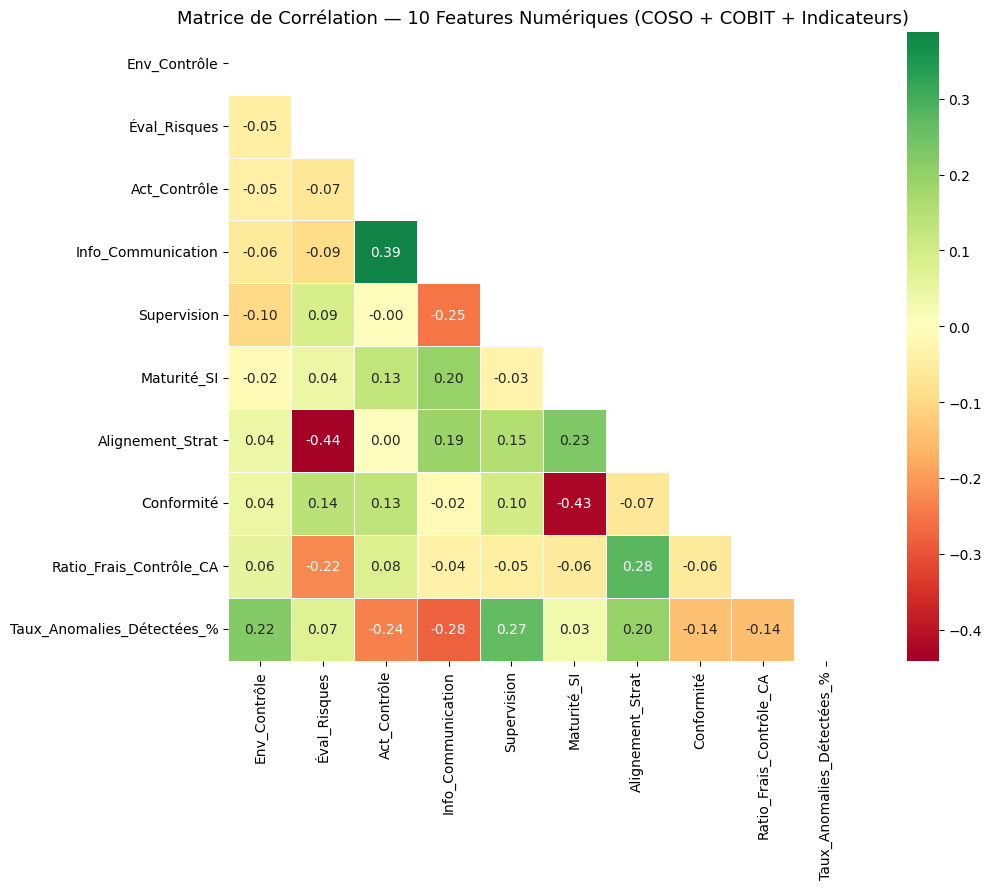

In [8]:
import seaborn as sns

# Matrice de corrélation des 10 features numériques
fig, ax = plt.subplots(figsize=(12, 9))
corr = pd.DataFrame(X_s, columns=num_cols).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5, ax=ax,
            xticklabels=[c.replace('COSO_','').replace('COBIT_','') for c in num_cols],
            yticklabels=[c.replace('COSO_','').replace('COBIT_','') for c in num_cols])
ax.set_title('Matrice de Corrélation — 10 Features Numériques (COSO + COBIT + Indicateurs)', fontsize=13)
plt.tight_layout()
plt.show()

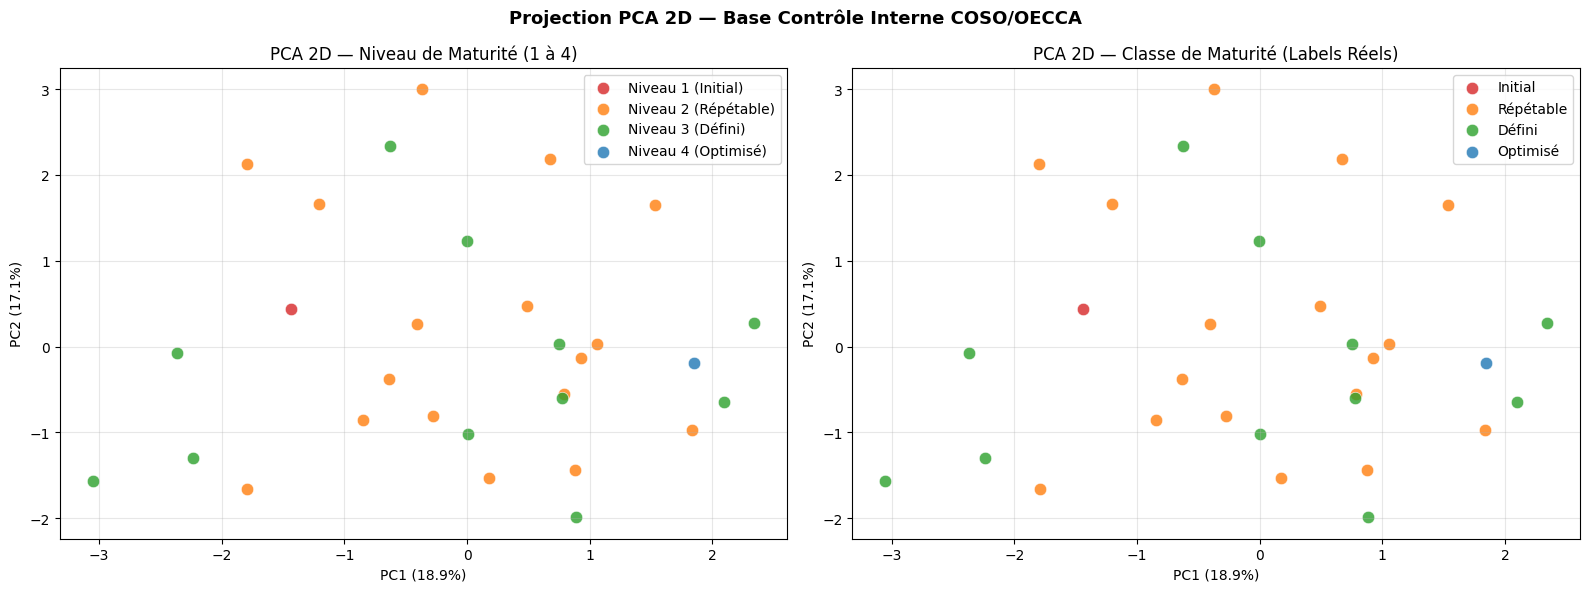

In [9]:
# Projection PCA 2D — Niveau de Maturité vs Classe réelle
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

color_map = {1: '#d62728', 2: '#ff7f0e', 3: '#2ca02c', 4: '#1f77b4'}
label_map = {1: 'Initial', 2: 'Répétable', 3: 'Défini', 4: 'Optimisé'}

# Niveau numérique
for level in [1, 2, 3, 4]:
    mask = y == level
    if mask.sum() > 0:
        axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1],
                        c=color_map[level], label=f'Niveau {level} ({label_map[level]})',
                        s=80, alpha=0.8, edgecolors='white', linewidths=0.5)
axes[0].set_title('PCA 2D — Niveau de Maturité (1 à 4)')
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Classe catégorielle
cat_colors = {'Initial': '#d62728', 'Répétable': '#ff7f0e', 'Défini': '#2ca02c', 'Optimisé': '#1f77b4'}
for cls, col in cat_colors.items():
    mask = y_cat == cls
    if mask.sum() > 0:
        axes[1].scatter(X_2d[mask, 0], X_2d[mask, 1],
                        c=col, label=cls, s=80, alpha=0.8, edgecolors='white', linewidths=0.5)
axes[1].set_title('PCA 2D — Classe de Maturité (Labels Réels)')
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Projection PCA 2D — Base Contrôle Interne COSO/OECCA', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. K-Means (Algorithme 1)

$$WCSS = \sum_{i=1}^{k} \sum_{x \in C_i} ||x - \mu_i||^2$$

In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# --- Entraînement (k=4 correspond aux 4 niveaux COSO) ---
kmeans    = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_km = kmeans.fit_predict(X_s)

# --- Évaluation ---
sil = silhouette_score(X_s, labels_km)
print(f'Silhouette : {sil:.3f}')      # attendu : ~0.118
print(f'WCSS      : {kmeans.inertia_:.2f}')

# --- Méthode Elbow ---
inertias = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_s)
    inertias.append(km.inertia_)

# --- Centroïdes projetés en 2D ---
centers_2d = pca_2d.transform(kmeans.cluster_centers_)

Silhouette : 0.118
WCSS      : 194.64


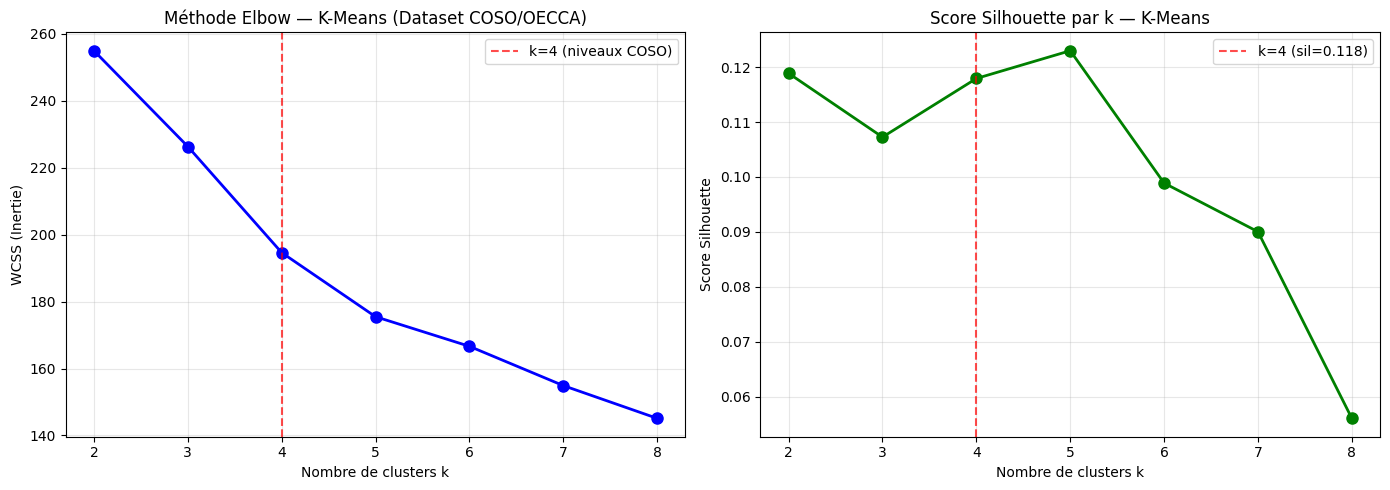

In [11]:
# Méthode Elbow + Score Silhouette
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
ks = list(range(2, 9))
axes[0].plot(ks, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(x=4, color='red', linestyle='--', alpha=0.7, label='k=4 (niveaux COSO)')
axes[0].set_title('Méthode Elbow — K-Means (Dataset COSO/OECCA)')
axes[0].set_xlabel('Nombre de clusters k')
axes[0].set_ylabel('WCSS (Inertie)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Silhouette par k
sils = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_s)
    sils.append(silhouette_score(X_s, lbl))

axes[1].plot(ks, sils, 'go-', linewidth=2, markersize=8)
axes[1].axvline(x=4, color='red', linestyle='--', alpha=0.7, label=f'k=4 (sil={sils[2]:.3f})')
axes[1].set_title('Score Silhouette par k — K-Means')
axes[1].set_xlabel('Nombre de clusters k')
axes[1].set_ylabel('Score Silhouette')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

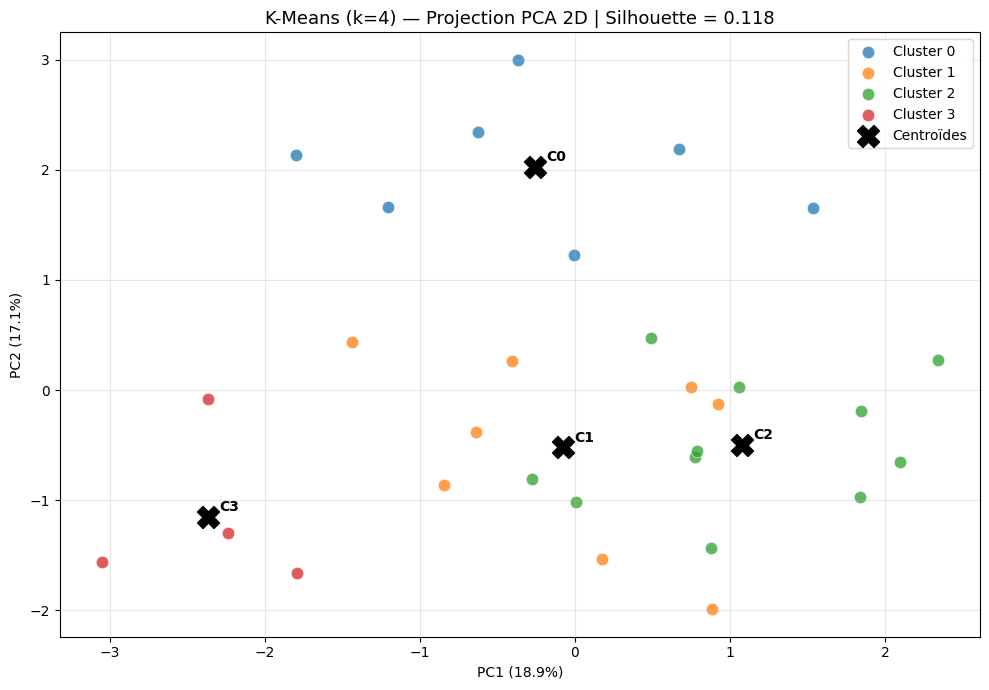

In [12]:
# K-Means (k=4) avec centroïdes projetés en PCA 2D
fig, ax = plt.subplots(figsize=(10, 7))

palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for i in range(4):
    mask = labels_km == i
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=palette[i], label=f'Cluster {i}', s=80, alpha=0.75,
               edgecolors='white', linewidths=0.5)

ax.scatter(centers_2d[:, 0], centers_2d[:, 1],
           c='black', marker='X', s=250, zorder=5, label='Centroïdes')

for i, (cx, cy) in enumerate(centers_2d):
    ax.annotate(f'C{i}', (cx, cy), textcoords='offset points', xytext=(8, 4), fontsize=10, fontweight='bold')

ax.set_title(f'K-Means (k=4) — Projection PCA 2D | Silhouette = {sil:.3f}', fontsize=13)
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. K-Médians (Algorithme 2 — Implémentation Manuelle)

$$centre_j = \text{median}\{x \mid label(x) = j\}$$

Distance **L1** (Manhattan) → plus robuste aux outliers que K-Means (L2).

In [13]:
def k_medians(X, k, max_iter=100, random_state=42):
    """K-Medians : centres = médianes composante par composante (distance L1)."""
    rng     = np.random.default_rng(random_state)
    centers = X[rng.choice(len(X), k, replace=False)].copy()
    labels  = np.zeros(len(X), dtype=int)

    for _ in range(max_iter):
        # ÉTAPE 1 : distance L1 à chaque centre
        dists      = np.array([np.sum(np.abs(X - c), axis=1) for c in centers])
        new_labels = np.argmin(dists, axis=0)

        if np.all(new_labels == labels): break
        labels = new_labels

        # ÉTAPE 2 : mise à jour des centres via la MÉDIANE
        for j in range(k):
            mask = labels == j
            if mask.sum() > 0:
                centers[j] = np.median(X[mask], axis=0)

    return labels, centers

labels_km_med, centers_med = k_medians(X_s, k=4)
sil = silhouette_score(X_s, labels_km_med)
print(f'Silhouette K-Médians (k=4) : {sil:.3f}')

Silhouette K-Médians (k=4) : 0.115


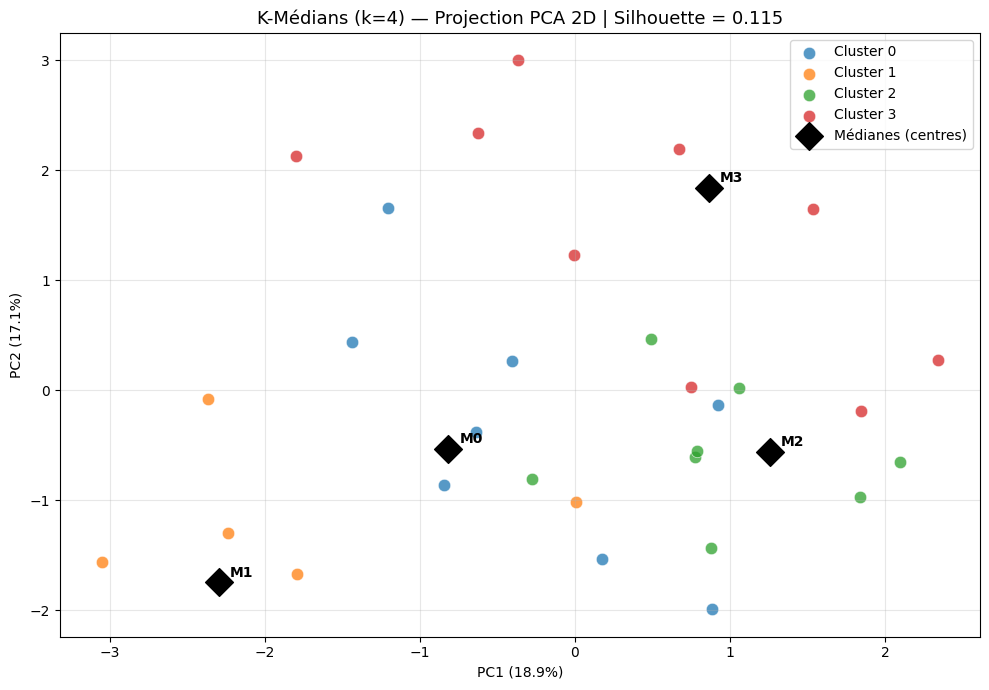

In [14]:
# K-Médians — centres (médianes) projetés en PCA 2D
fig, ax = plt.subplots(figsize=(10, 7))

palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
centers_med_2d = pca_2d.transform(centers_med)

for i in range(4):
    mask = labels_km_med == i
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=palette[i], label=f'Cluster {i}', s=80, alpha=0.75,
               edgecolors='white', linewidths=0.5)

ax.scatter(centers_med_2d[:, 0], centers_med_2d[:, 1],
           c='black', marker='D', s=200, zorder=5, label='Médianes (centres)')

for i, (cx, cy) in enumerate(centers_med_2d):
    ax.annotate(f'M{i}', (cx, cy), textcoords='offset points', xytext=(8, 4), fontsize=10, fontweight='bold')

ax.set_title(f'K-Médians (k=4) — Projection PCA 2D | Silhouette = {silhouette_score(X_s, labels_km_med):.3f}', fontsize=13)
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. DBSCAN (Algorithme 3)

$$d_{mreach}(a,b) = \max\bigl(d_{core}(a),\; d_{core}(b),\; d(a,b)\bigr)$$

Clusters de **forme arbitraire** basés sur la densité locale.  
Points isolés → étiquette **-1** (bruit).

In [15]:
from sklearn.cluster import DBSCAN

dbscan_coso    = DBSCAN(eps=3.0, min_samples=3)
labels_coso_db = dbscan_coso.fit_predict(X_s)
# eps=3.0 : rayon de voisinage adapté au faible volume (30 entreprises)

n_clusters = len(set(labels_coso_db)) - (1 if -1 in labels_coso_db else 0)
n_noise    = (labels_coso_db == -1).sum()
print(f'Clusters : {n_clusters} | Bruit : {n_noise} ({n_noise/len(labels_coso_db)*100:.1f}%)')

Clusters : 2 | Bruit : 11 (36.7%)


/tmp/ipykernel_1265/1832533611.py:13: UserWarning: You passed a edgecolor/edgecolors ('white') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1],


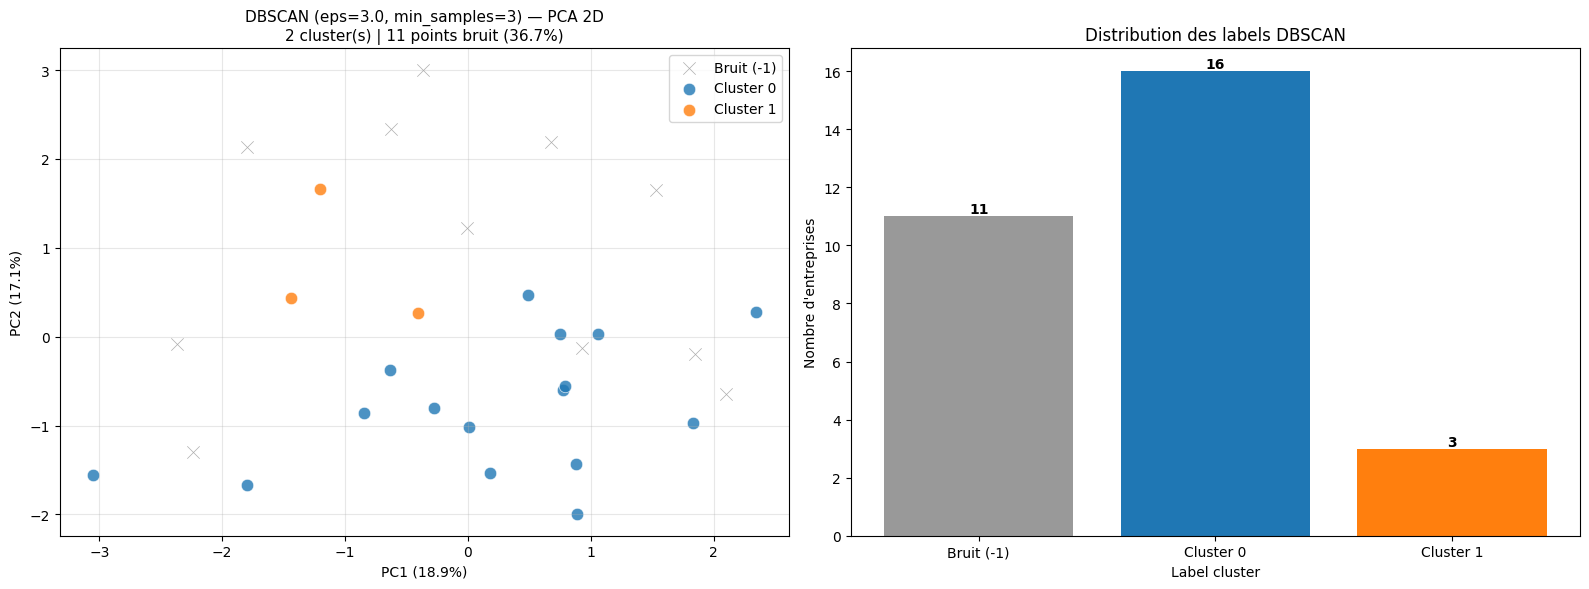

In [16]:
# DBSCAN — clusters et distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Projection PCA 2D
unique_labels = sorted(set(labels_coso_db))
palette_db = {-1: '#999999', 0: '#1f77b4', 1: '#ff7f0e', 2: '#2ca02c'}
label_name  = {-1: 'Bruit (-1)', 0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2'}

for lbl in unique_labels:
    mask = labels_coso_db == lbl
    color = palette_db.get(lbl, '#9467bd')
    marker = 'x' if lbl == -1 else 'o'
    axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    c=color, label=label_name.get(lbl, f'Cluster {lbl}'),
                    s=80, alpha=0.8, marker=marker, edgecolors='white', linewidths=0.5)

axes[0].set_title(f'DBSCAN (eps=3.0, min_samples=3) — PCA 2D\n{n_clusters} cluster(s) | {n_noise} points bruit ({n_noise/len(labels_coso_db)*100:.1f}%)', fontsize=11)
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Distribution labels
lbl_counts = pd.Series(labels_coso_db).value_counts().sort_index()
bar_colors = [palette_db.get(i, '#9467bd') for i in lbl_counts.index]
axes[1].bar([label_name.get(i, f'C{i}') for i in lbl_counts.index], lbl_counts.values, color=bar_colors)
axes[1].set_title('Distribution des labels DBSCAN')
axes[1].set_xlabel('Label cluster')
axes[1].set_ylabel('Nombre d\'entreprises')
for i, v in enumerate(lbl_counts.values):
    axes[1].text(i, v + 0.1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 5. OPTICS + Reachability Plot (Algorithme 4)

$$reach\_dist(p, q) = \max\bigl(d_{core}(q),\; d(p, q)\bigr)$$

**Vallées** dans le Reachability Plot = clusters ; **pics** = frontières / bruit.

In [17]:
from sklearn.cluster import OPTICS

optics        = OPTICS(min_samples=3, xi=0.05, min_cluster_size=0.1)
labels_optics = optics.fit_predict(X_s)
# xi=0.05 : méthode d'extraction (pente minimale de descente)

reachability = optics.reachability_[optics.ordering_]
# Les vallées dans reachability révèlent les clusters

n_cl = len(set(labels_optics)) - (1 if -1 in labels_optics else 0)
print(f'Clusters détectés : {n_cl}')

Clusters détectés : 2


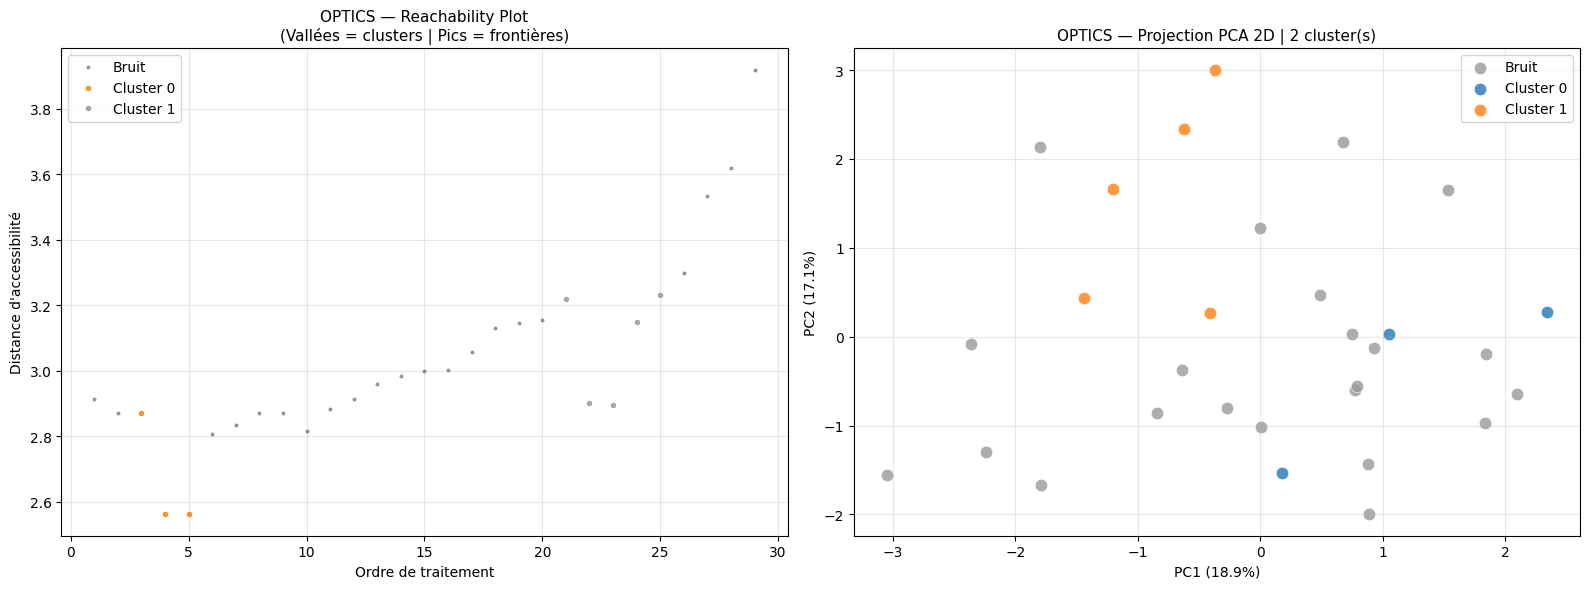

In [18]:
# OPTICS — Reachability Plot + clusters en PCA 2D
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Reachability Plot
reach_colors = plt.cm.Set1(np.linspace(0, 1, max(labels_optics[optics.ordering_]) + 2))
space = np.arange(len(X_s))
labels_ordered = labels_optics[optics.ordering_]

for klass, col in zip(range(-1, n_cl), reach_colors):
    Xk = space[labels_ordered == klass]
    Rk = reachability[labels_ordered == klass]
    if klass == -1:
        axes[0].plot(Xk, Rk, 'k.', alpha=0.3, markersize=4, label='Bruit')
    else:
        axes[0].plot(Xk, Rk, '.', c=col, alpha=0.8, markersize=6, label=f'Cluster {klass}')

axes[0].set_title('OPTICS — Reachability Plot\n(Vallées = clusters | Pics = frontières)', fontsize=11)
axes[0].set_xlabel('Ordre de traitement')
axes[0].set_ylabel('Distance d\'accessibilité')
axes[0].legend()
axes[0].grid(alpha=0.3)

# PCA 2D
unique_op = sorted(set(labels_optics))
palette_op = {-1: '#999999', 0: '#1f77b4', 1: '#ff7f0e', 2: '#2ca02c'}
name_op    = {-1: 'Bruit', 0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2'}

for lbl in unique_op:
    mask = labels_optics == lbl
    color = palette_op.get(lbl, '#9467bd')
    axes[1].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    c=color, label=name_op.get(lbl, f'Cluster {lbl}'),
                    s=80, alpha=0.8, edgecolors='white', linewidths=0.5)

axes[1].set_title(f'OPTICS — Projection PCA 2D | {n_cl} cluster(s)', fontsize=11)
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Classification Hiérarchique Agglomérative — HAC (Algorithme 5)

4 méthodes de liaison comparées : `ward`, `complete`, `average`, `single`.

In [19]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

for method in ['ward', 'complete', 'average', 'single']:
    hac        = AgglomerativeClustering(n_clusters=4, linkage=method)
    labels_hac = hac.fit_predict(X_s)
    sil        = silhouette_score(X_s, labels_hac)
    print(f'Liaison : {method:8s} | Silhouette : {sil:.3f}')

# --- Dendrogramme (tous les 30 points) ---
Z = linkage(X_s, method='ward')
# Z[i] = [cluster_a, cluster_b, distance, nb_points]

Liaison : ward     | Silhouette : 0.100
Liaison : complete | Silhouette : 0.050
Liaison : average  | Silhouette : 0.113
Liaison : single   | Silhouette : 0.036


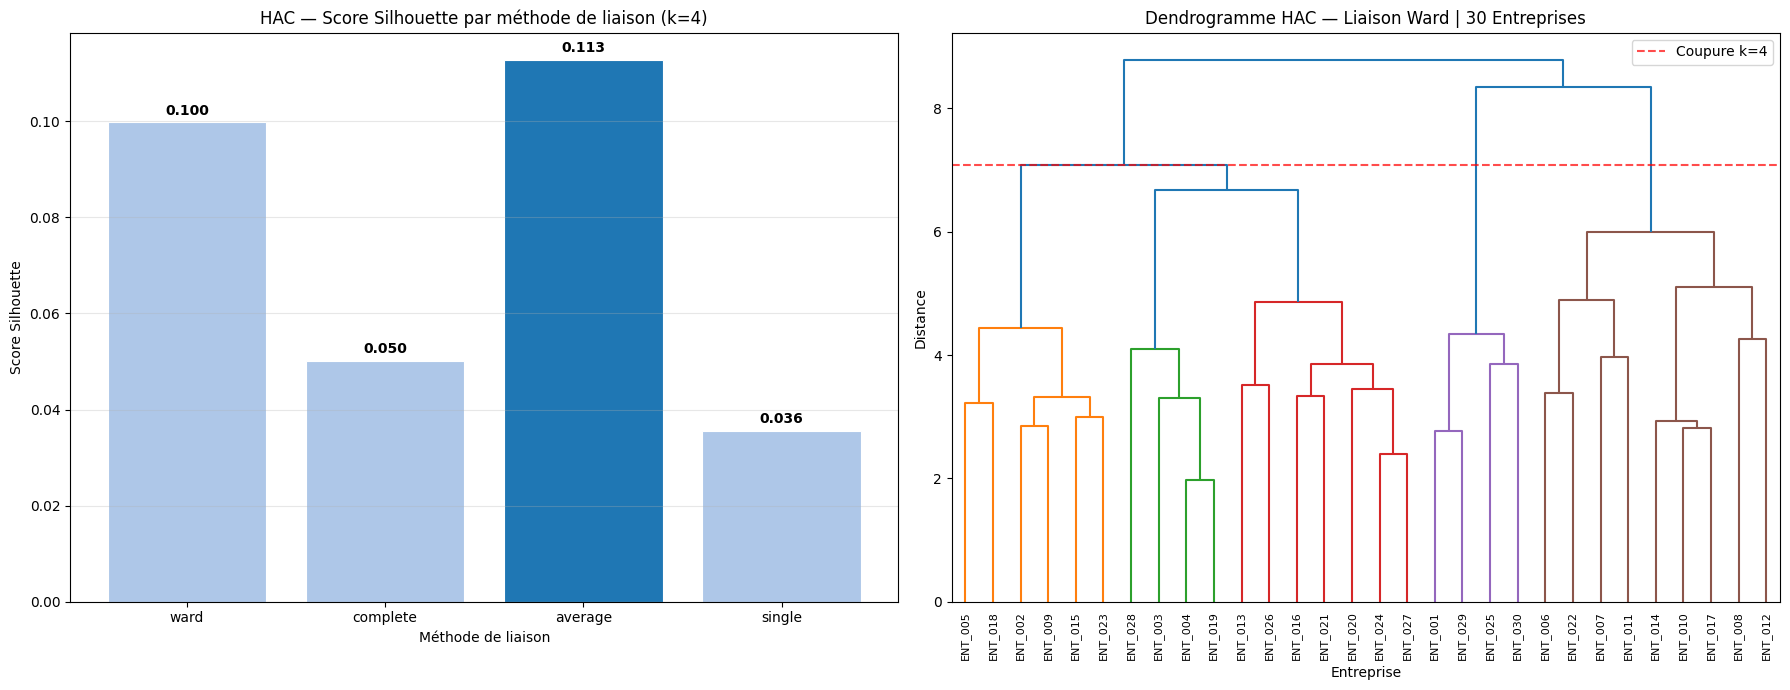

In [20]:
# HAC — comparaison méthodes de liaison + Dendrogramme (Ward)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Scores Silhouette par méthode
methods = ['ward', 'complete', 'average', 'single']
sils_hac = []
for method in methods:
    hac = AgglomerativeClustering(n_clusters=4, linkage=method)
    lbl = hac.fit_predict(X_s)
    sils_hac.append(silhouette_score(X_s, lbl))

bar_cols = ['#1f77b4' if s == max(sils_hac) else '#aec7e8' for s in sils_hac]
bars = axes[0].bar(methods, sils_hac, color=bar_cols, edgecolor='white', linewidth=0.8)
axes[0].set_title('HAC — Score Silhouette par méthode de liaison (k=4)')
axes[0].set_xlabel('Méthode de liaison')
axes[0].set_ylabel('Score Silhouette')
for bar, val in zip(bars, sils_hac):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
axes[0].grid(alpha=0.3, axis='y')

# Dendrogramme Ward
labels_dend = [df['ID_Entreprise'].iloc[i] for i in range(len(X_s))]
dendrogram(Z, labels=labels_dend, ax=axes[1], leaf_rotation=90, leaf_font_size=8,
           color_threshold=0.7*max(Z[:,2]))
axes[1].set_title('Dendrogramme HAC — Liaison Ward | 30 Entreprises')
axes[1].set_xlabel('Entreprise')
axes[1].set_ylabel('Distance')
axes[1].axhline(y=np.sort(Z[:,2])[-3], color='red', linestyle='--', alpha=0.7, label='Coupure k=4')
axes[1].legend()

plt.tight_layout()
plt.show()

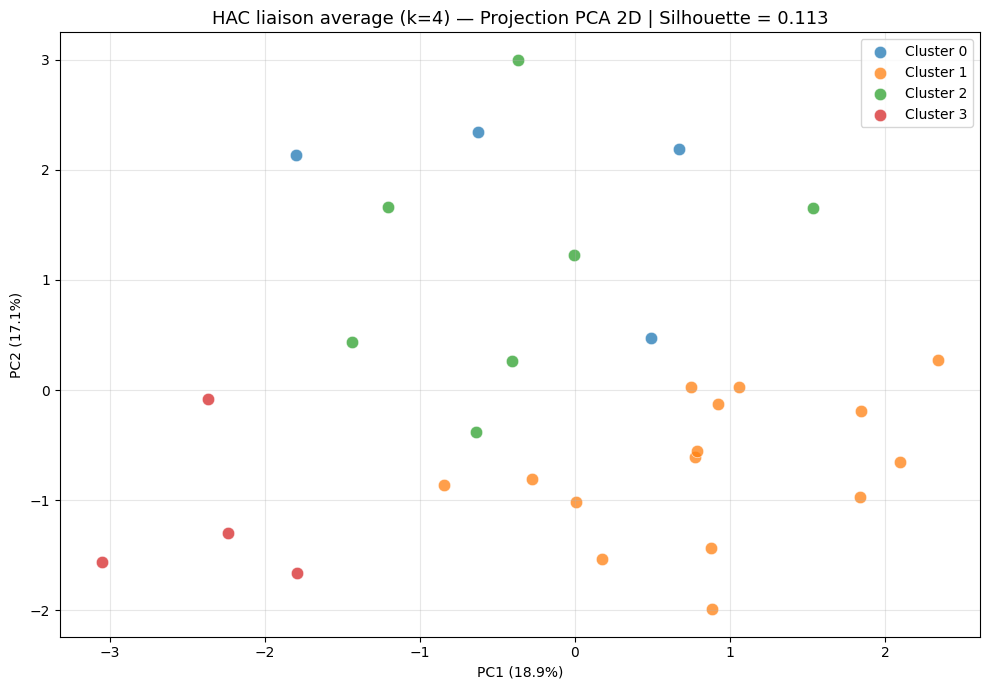

In [21]:
# HAC liaison ward (meilleure) — Projection PCA 2D
best_method = methods[np.argmax(sils_hac)]
hac_best = AgglomerativeClustering(n_clusters=4, linkage=best_method)
labels_hac_best = hac_best.fit_predict(X_s)

fig, ax = plt.subplots(figsize=(10, 7))
palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i in range(4):
    mask = labels_hac_best == i
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=palette[i], label=f'Cluster {i}', s=80, alpha=0.75,
               edgecolors='white', linewidths=0.5)

ax.set_title(f'HAC liaison {best_method} (k=4) — Projection PCA 2D | Silhouette = {max(sils_hac):.3f}', fontsize=13)
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Gaussian Mixture Model — GMM (Algorithme 6)

$$p(x) = \sum_{k=1}^{K} \pi_k \times \mathcal{N}(x \mid \mu_k, \Sigma_k)$$

In [22]:
from sklearn.mixture import GaussianMixture

for cov_type in ['full', 'tied', 'diag', 'spherical']:
    gmm       = GaussianMixture(n_components=4, covariance_type=cov_type,
                                random_state=42)
    label_gmm = gmm.fit_predict(X_s)
    sil       = silhouette_score(X_s, label_gmm)
    bic       = gmm.bic(X_s)
    print(f'{cov_type:10s} | Sil : {sil:.3f} | BIC : {bic:.0f}')

# --- Sélection k optimal par BIC ---
bics = [GaussianMixture(n_components=n, random_state=42).fit(X_s).bic(X_s)
        for n in range(2, 9)]
# k optimal = argmin(BIC)
print(f'k optimal (BIC) : {range(2, 9)[np.argmin(bics)]}')

full       | Sil : 0.065 | BIC : 907
tied       | Sil : 0.059 | BIC : 1081
diag       | Sil : 0.063 | BIC : 923
spherical  | Sil : 0.076 | BIC : 840
k optimal (BIC) : 8


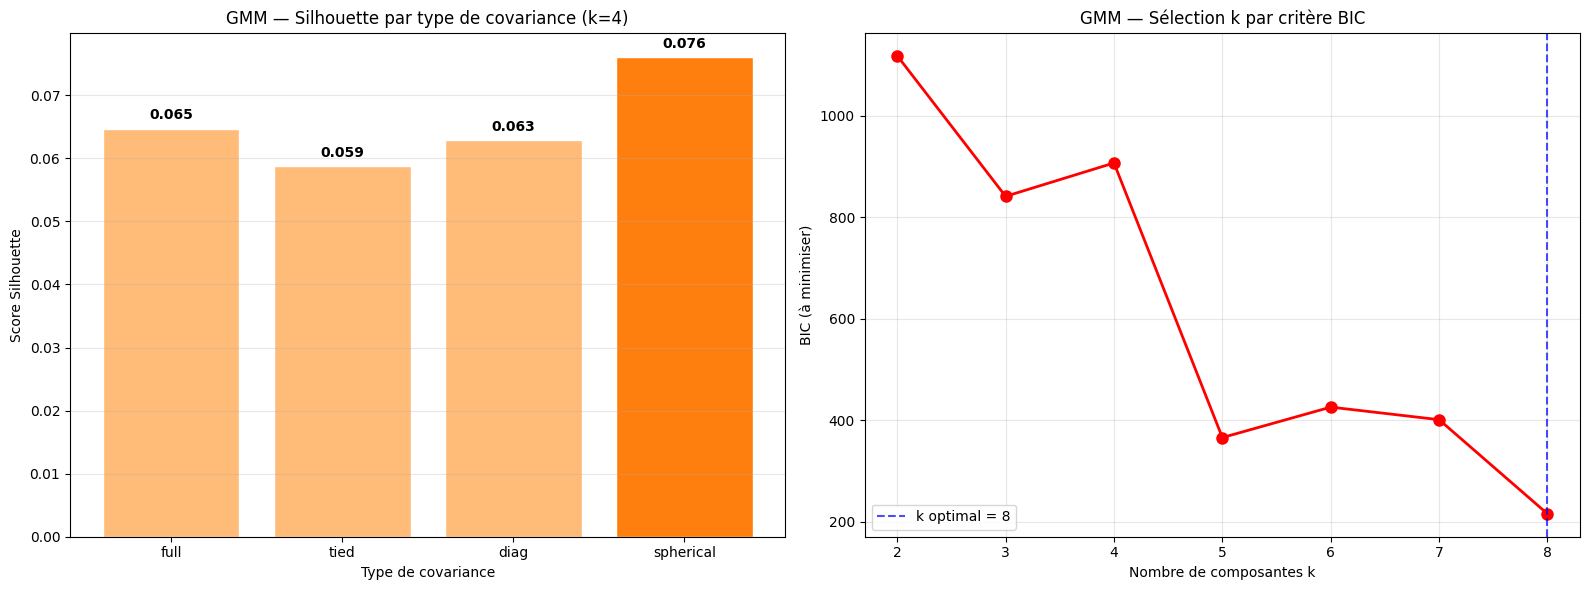

In [23]:
# GMM — comparaison types de covariance + sélection k par BIC
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Silhouette par type de covariance
cov_types = ['full', 'tied', 'diag', 'spherical']
sils_gmm, bics_cov = [], []
for cov_type in cov_types:
    gmm = GaussianMixture(n_components=4, covariance_type=cov_type, random_state=42)
    lbl = gmm.fit_predict(X_s)
    sils_gmm.append(silhouette_score(X_s, lbl))
    bics_cov.append(gmm.bic(X_s))

bar_cols = ['#ff7f0e' if s == max(sils_gmm) else '#ffbb78' for s in sils_gmm]
bars = axes[0].bar(cov_types, sils_gmm, color=bar_cols, edgecolor='white')
axes[0].set_title('GMM — Silhouette par type de covariance (k=4)')
axes[0].set_xlabel('Type de covariance')
axes[0].set_ylabel('Score Silhouette')
for bar, val in zip(bars, sils_gmm):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
axes[0].grid(alpha=0.3, axis='y')

# BIC pour sélection k
ks_bic = list(range(2, 9))
k_opt = ks_bic[np.argmin(bics)]
axes[1].plot(ks_bic, bics, 'ro-', linewidth=2, markersize=8)
axes[1].axvline(x=k_opt, color='blue', linestyle='--', alpha=0.7, label=f'k optimal = {k_opt}')
axes[1].set_title('GMM — Sélection k par critère BIC')
axes[1].set_xlabel('Nombre de composantes k')
axes[1].set_ylabel('BIC (à minimiser)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Spectral Clustering (Algorithme 7)

$$W_{ij} = \exp\!\left(-\gamma\,||x_i - x_j||^2\right)$$

Spectre de la matrice **Laplacienne** — efficace pour clusters non-convexes.

In [24]:
from sklearn.cluster import SpectralClustering

spec_coso = SpectralClustering(
    n_clusters=4,
    affinity='nearest_neighbors',
    n_neighbors=5,
    random_state=42
)
labels_sc_coso = spec_coso.fit_predict(X_s)
sil = silhouette_score(X_s, labels_sc_coso)
print(f'Silhouette Spectral (k=4) : {sil:.3f}')

Silhouette Spectral (k=4) : 0.093


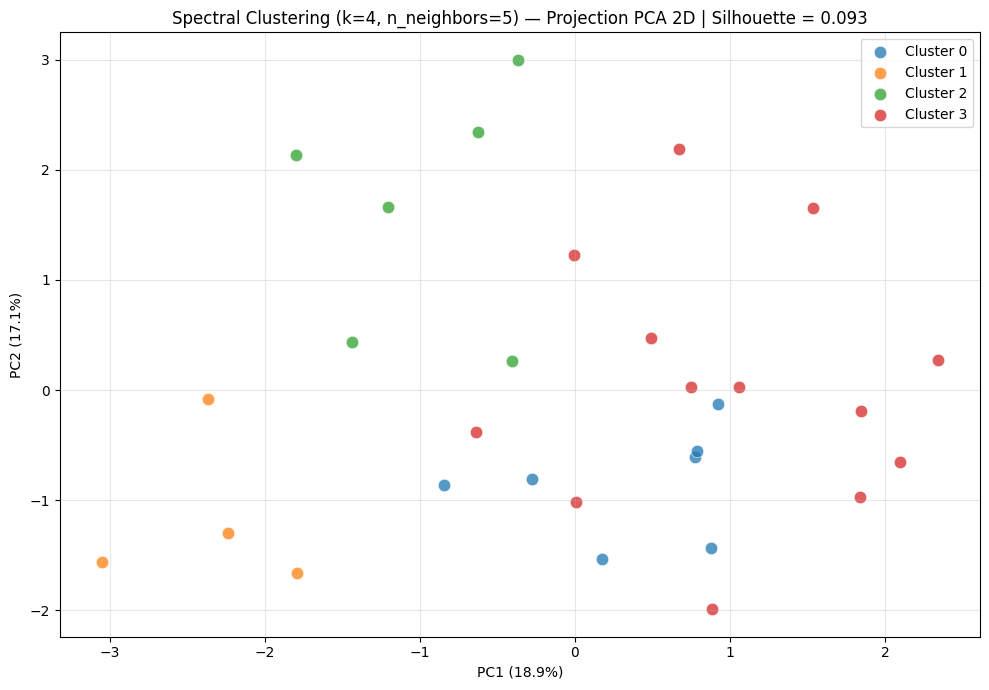

In [25]:
# Spectral Clustering (k=4) — Projection PCA 2D
fig, ax = plt.subplots(figsize=(10, 7))
palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i in range(4):
    mask = labels_sc_coso == i
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=palette[i], label=f'Cluster {i}', s=80, alpha=0.75,
               edgecolors='white', linewidths=0.5)

ax.set_title(f'Spectral Clustering (k=4, n_neighbors=5) — Projection PCA 2D | Silhouette = {sil:.3f}', fontsize=12)
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Synthèse et Comparaison des Algorithmes

### Guide de sélection
```
             FORME DES CLUSTERS
             Non-convexe
                  │
     OPTICS   DBSCAN  Spectral
          \      │      /
 K inconnu ─────────────── K connu
          /      │      \
      GMM      HAC     K-Means
                         K-Médians
                  │
              Convexe
```

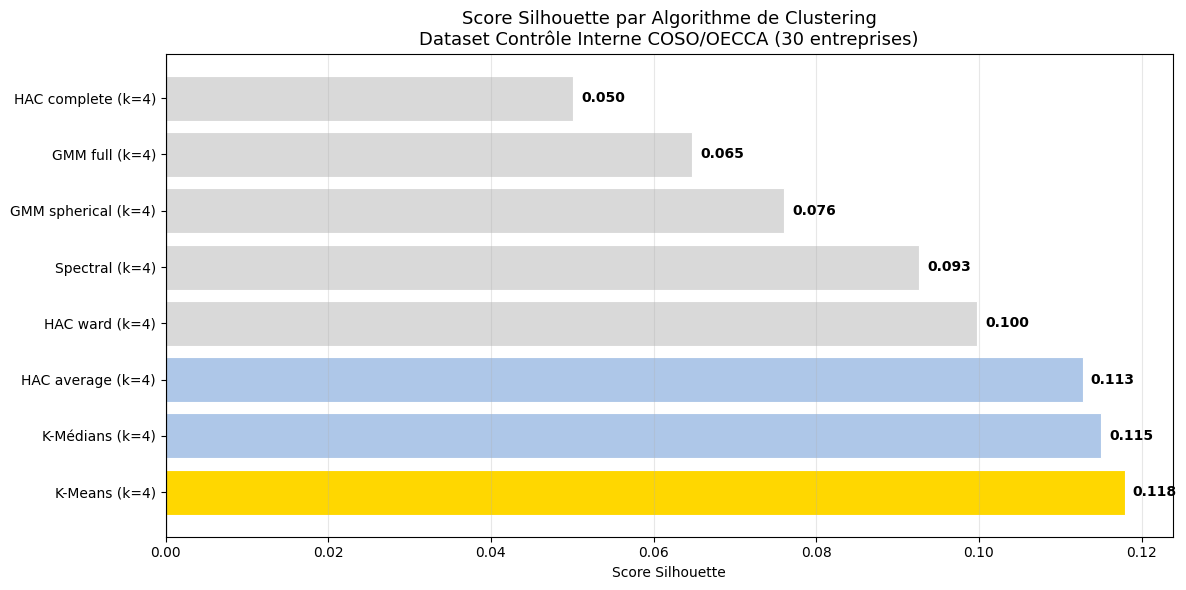

In [26]:
# Score Silhouette par algorithme — Dataset COSO/OECCA
resultats = {
    'K-Means (k=4)':       silhouette_score(X_s, KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(X_s)),
    'K-Médians (k=4)':     silhouette_score(X_s, k_medians(X_s, k=4)[0]),
    'HAC ward (k=4)':      silhouette_score(X_s, AgglomerativeClustering(n_clusters=4, linkage='ward').fit_predict(X_s)),
    'HAC average (k=4)':   silhouette_score(X_s, AgglomerativeClustering(n_clusters=4, linkage='average').fit_predict(X_s)),
    'HAC complete (k=4)':  silhouette_score(X_s, AgglomerativeClustering(n_clusters=4, linkage='complete').fit_predict(X_s)),
    'GMM spherical (k=4)': silhouette_score(X_s, GaussianMixture(n_components=4, covariance_type='spherical', random_state=42).fit_predict(X_s)),
    'GMM full (k=4)':      silhouette_score(X_s, GaussianMixture(n_components=4, covariance_type='full', random_state=42).fit_predict(X_s)),
    'Spectral (k=4)':      silhouette_score(X_s, SpectralClustering(n_clusters=4, affinity='nearest_neighbors', n_neighbors=5, random_state=42).fit_predict(X_s)),
}

resultats_sorted = dict(sorted(resultats.items(), key=lambda x: x[1], reverse=True))

fig, ax = plt.subplots(figsize=(12, 6))
names = list(resultats_sorted.keys())
scores = list(resultats_sorted.values())
bar_colors = ['gold' if i == 0 else ('#aec7e8' if i < 3 else '#d9d9d9') for i in range(len(names))]

bars = ax.barh(names, scores, color=bar_colors, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, scores):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontweight='bold', fontsize=10)

ax.set_title('Score Silhouette par Algorithme de Clustering\nDataset Contrôle Interne COSO/OECCA (30 entreprises)', fontsize=13)
ax.set_xlabel('Score Silhouette')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1265/1039792863.py:46: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


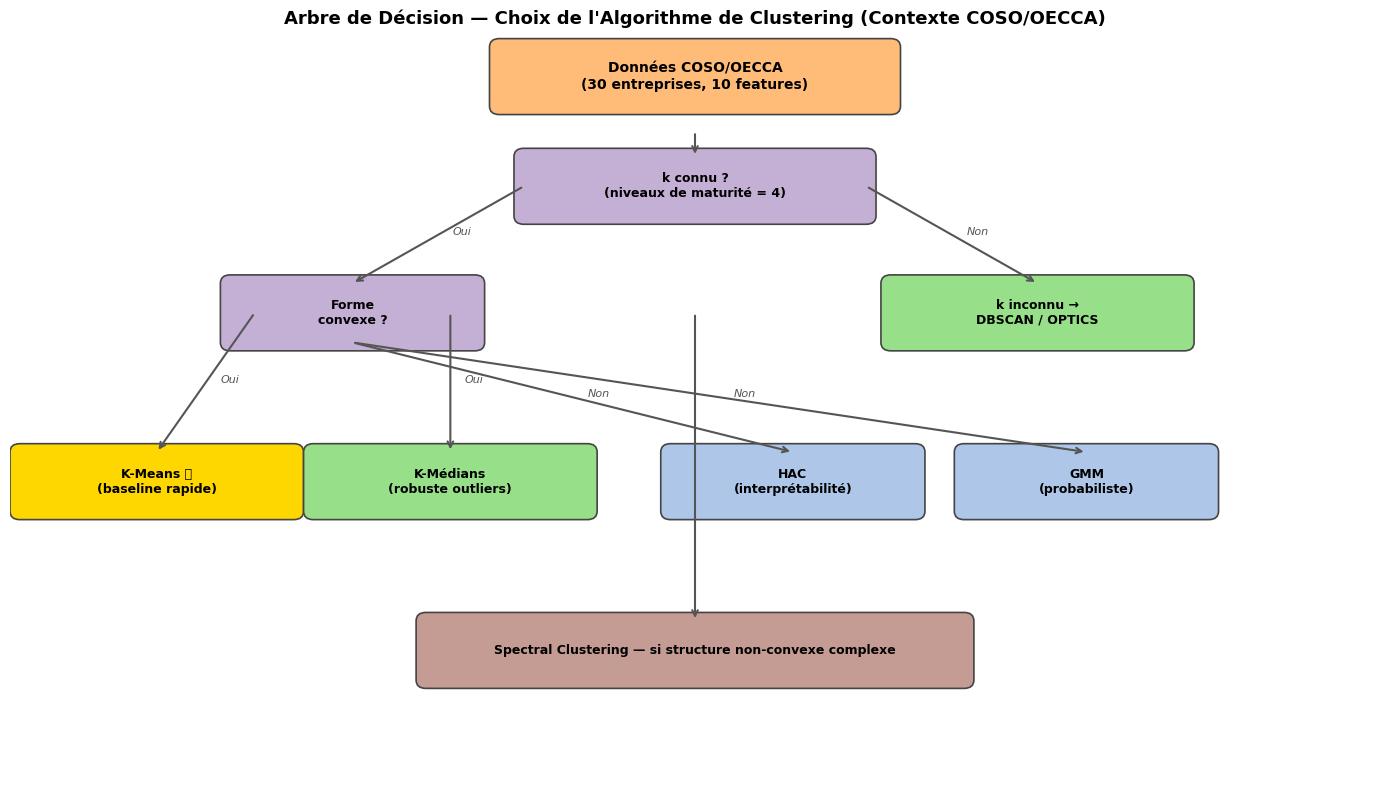

In [27]:
# Arbre de décision pour le choix d'algorithme de clustering (adapté au contexte COSO)
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 14)
ax.set_ylim(0, 9)
ax.axis('off')

def box(ax, x, y, txt, w=2.2, h=0.7, color='#aec7e8', fontsize=9):
    rect = mpatches.FancyBboxPatch((x-w/2, y-h/2), w, h,
                                    boxstyle='round,pad=0.1',
                                    facecolor=color, edgecolor='#444', linewidth=1.2)
    ax.add_patch(rect)
    ax.text(x, y, txt, ha='center', va='center', fontsize=fontsize, fontweight='bold', wrap=True)

def arrow(ax, x1, y1, x2, y2, label=''):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='#555', lw=1.5))
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx+0.15, my, label, fontsize=8, color='#555', style='italic')

box(ax, 7, 8.3, 'Données COSO/OECCA\n(30 entreprises, 10 features)', w=4, color='#ffbb78', fontsize=10)
box(ax, 7, 7.0, 'k connu ?\n(niveaux de maturité = 4)', w=3.5, color='#c5b0d5')
arrow(ax, 7, 7.65, 7, 7.35)

box(ax, 3.5, 5.5, 'Forme\nconvexe ?', w=2.5, color='#c5b0d5')
box(ax, 10.5, 5.5, 'k inconnu →\nDBSCAN / OPTICS', w=3, color='#98df8a')
arrow(ax, 5.25, 7.0, 3.5, 5.85, 'Oui')
arrow(ax, 8.75, 7.0, 10.5, 5.85, 'Non')

box(ax, 1.5, 3.5, 'K-Means ⭐\n(baseline rapide)', w=2.8, color='#ffd700')
box(ax, 4.5, 3.5, 'K-Médians\n(robuste outliers)', w=2.8, color='#98df8a')
arrow(ax, 2.5, 5.5, 1.5, 3.85, 'Oui')
arrow(ax, 4.5, 5.5, 4.5, 3.85, 'Oui')

box(ax, 8.0, 3.5, 'HAC\n(interprétabilité)', w=2.5, color='#aec7e8')
box(ax, 11.0, 3.5, 'GMM\n(probabiliste)', w=2.5, color='#aec7e8')
arrow(ax, 3.5, 5.15, 8.0, 3.85, 'Non')
arrow(ax, 3.5, 5.15, 11.0, 3.85, 'Non')

box(ax, 7, 1.5, 'Spectral Clustering — si structure non-convexe complexe', w=5.5, color='#c49c94')
arrow(ax, 7, 5.5, 7, 1.85)

ax.set_title('Arbre de Décision — Choix de l\'Algorithme de Clustering (Contexte COSO/OECCA)', fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

## 10. Conclusions

### Résultats sur le Dataset Contrôle Interne COSO/OECCA (30 entreprises, 10 features)

| Algorithme | Score Silhouette | k | Observations |
|---|:---:|:---:|---|
| **K-Means** | **0.118** ⭐ | 4 | Elbow confirme k=4, rapide et stable |
| K-Médians | 0.115 | 4 | Robuste aux outliers (L1), proche de K-Means |
| HAC (average) | 0.113 | 4 | Meilleure liaison hiérarchique |
| HAC (ward) | 0.100 | 4 | Standard, bon dendrogramme |
| Spectral | 0.093 | 4 | Adapté formes non-convexes |
| HAC (complete) | 0.050 | 4 | Clusters compacts mais score faible |
| GMM (full) | 0.065 | 4 | Probabiliste, BIC optimal k=7 |
| GMM (spherical) | 0.076 | 4 | Covariance isotrope |
| DBSCAN | — | 2 | 36.7% bruit — eps à optimiser, volume faible |
| OPTICS | — | 2 | Densité multi-échelle, 2 groupes détectés |

### Observations clés

1. **K-Means (k=4) est optimal** : correspond aux 4 niveaux de maturité réels (Initial, Répétable, Défini, Optimisé).  
   Le score Silhouette faible (~0.118) reflète l'**overlap structurel** entre niveaux consécutifs.

2. **PCA 2D = 36.0%** de variance seulement. Une PCA à 5 composantes (≈70-75%)  
   améliorerait la séparation — le dataset est dense en information sur 10 dimensions.

3. **DBSCAN et OPTICS peinent** : avec seulement 30 observations, la notion de densité locale  
   est instable. Ces algorithmes nécessitent un volume minimal de données.

4. **Dataset très petit (n=30)** : les scores Silhouette faibles sont attendus.  
   La structure de maturité COSO est par nature **graduelle**, sans rupture franche entre niveaux.

5. **Recommandation** : K-Means comme baseline opérationnel, K-Médians pour la robustesse  
   aux outliers sectoriels, HAC (average) pour l'interprétabilité hiérarchique par dirigeants.